In [3]:
import xarray as xr
import xesmf as xe
import numpy as np
import os
from pathlib import Path
import time as pytime

# ----------------------
# 1. Load only one ORCA36 file (lazy, Dask-friendly)
ds_model = xr.open_dataset(
    "Mercator_hierarchy/ORCA36/daily/ORCA36-T426_1dAV_20180101-20180101_gridT.nc",
    chunks="auto",  # let Dask decide automatically
)

ds_model = ds_model.sortby("time_counter")

print(ds_model)

# ----------------------
# 2. Slice full Weddell Sea region
lon_min, lon_max = -70, -10
lat_min, lat_max = -80, -60

# Load lat/lon coordinates lazily
lon2d = ds_model["nav_lon"].values
lat2d = ds_model["nav_lat"].values

y_flat, x_flat = np.indices(lon2d.shape)
flat_mask = (lat2d >= lat_min) & (lat2d <= lat_max) & (lon2d >= lon_min) & (lon2d <= lon_max)

if not np.any(flat_mask):
    lat_center = (lat_min + lat_max)/2
    lon_center = (lon_min + lon_max)/2
    idx = np.argmin((lat2d - lat_center)**2 + (lon2d - lon_center)**2)
    y_inds = [np.unravel_index(idx, lat2d.shape)[0]]
    x_inds = [np.unravel_index(idx, lon2d.shape)[1]]
else:
    y_inds = np.unique(y_flat[flat_mask])
    x_inds = np.unique(x_flat[flat_mask])

ds_model_sub_surf = ds_model.isel(
    deptht=0,
    y=slice(y_inds.min(), y_inds.max()+1),
    x=slice(x_inds.min(), x_inds.max()+1)
)

# ----------------------
# 3. Keep only needed variables
vars_to_keep = ["thetao", "so", "nav_lat", "nav_lon"]
ds_model_sub_surf = ds_model_sub_surf[vars_to_keep]

# ----------------------
# 4. Take monthly means (lazy)
ds_model_sub_monthly_surf = ds_model_sub_surf.resample(time_counter="1MS").mean()
print(ds_model_sub_monthly_surf)

# ----------------------
# 5. Load observational dataset (target grid)
ds_obs = xr.open_dataset("woa23/woa23_B5C2_t01_04.nc", decode_times=False)
ds_obs_sub = ds_obs.sel(
    lat=slice(lat_min, lat_max) if ds_obs.lat[0] < ds_obs.lat[-1] else slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

grid_out = xr.Dataset(
    coords={
        "lat": ds_obs_sub["lat"],
        "lon": ds_obs_sub["lon"]
    }
)

grid_in = ds_model_sub_monthly_surf.isel(time_counter=0)

# ----------------------
# 6. Create or reuse xESMF regridder
weight_file = "weights_weddell_woa.nc"
reuse = os.path.exists(weight_file)

if reuse:
    print("Loading existing regridder weights...")
else:
    print("Creating new regridder and saving weights...")

regridder = xe.Regridder(
    grid_in,
    grid_out,
    method="bilinear",
    filename=weight_file,
    reuse_weights=reuse,
    ignore_degenerate=True,
    extrap_method=None
)

print("Regridder ready.")

# ----------------------
# 7. Chunking experiments (time fixed, test horizontal chunks)
chunk_sizes = [80, 160, 320]  # horizontal chunk sizes
results = []

for c in chunk_sizes:
    print(f"\n--- Testing horizontal chunk size: {c} ---")
    
    # Rechunk spatial dimensions only
    ds_chunked = ds_model_sub_monthly_surf.chunk({'time_counter': 1, 'y': c, 'x': c})
    
    # Apply regridder lazily
    ds_regridded_lazy = xr.Dataset(
        {var: regridder(ds_chunked[var]) for var in ["thetao", "so"]},
        coords={
            "time_counter": ds_chunked["time_counter"],
            "lat": grid_out["lat"],
            "lon": grid_out["lon"]
        }
    )
    
    # Timer
    start = pytime.time()
    ds_regridded = ds_regridded_lazy.compute()
    end = pytime.time()
    
    size_MB = ds_regridded.nbytes / 1024**2
    elapsed = end - start
    results.append({'chunk_size': c, 'time_s': elapsed, 'size_MB': size_MB})
    
    print(f"Chunk {c}: time={elapsed:.2f}s, size={size_MB:.3f} MB")

print("\nAll results:")
for r in results:
    print(r)





getfattr: /home1/datahome/skaram/Mercator_hierarchy/ORCA36/daily/ORCA36-T426_1dAV_20180101-20180101_gridT.nc: Operation not supported


<xarray.Dataset> Size: 128GB
Dimensions:               (deptht: 75, axis_nbounds: 2, time_counter: 1,
                           y: 10842, x: 12960)
Coordinates:
  * deptht                (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 8B 2018-01-01T12:00:00
    time_centered         (time_counter) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
    time_instant          (time_counter) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float32 562MB dask.array<chunksize=(2507, 12960), meta=np.ndarray>
    nav_lon               (y, x) float32 562MB dask.array<chunksize=(2507, 12960), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables:
    deptht_bounds         (deptht, axis_nbounds) float32 600B dask.array<chunksize=(75, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 16B dask.array<chunksize=(1, 2),

getfattr: /home1/datahome/skaram/woa23/woa23_B5C2_t01_04.nc: Operation not supported


Loading existing regridder weights...


getfattr: /home1/datahome/skaram/weights_weddell_woa.nc: Operation not supported


Regridder ready.

--- Testing horizontal chunk size: 80 ---
Chunk 80: time=5.52s, size=0.148 MB

--- Testing horizontal chunk size: 160 ---
Chunk 160: time=4.40s, size=0.148 MB

--- Testing horizontal chunk size: 320 ---
Chunk 320: time=4.27s, size=0.148 MB

All results:
{'chunk_size': 80, 'time_s': 5.52238392829895, 'size_MB': 0.14771652221679688}
{'chunk_size': 160, 'time_s': 4.400437116622925, 'size_MB': 0.14771652221679688}
{'chunk_size': 320, 'time_s': 4.267688989639282, 'size_MB': 0.14771652221679688}


In [4]:
print(ds_regridded)

<xarray.Dataset> Size: 155kB
Dimensions:       (time_counter: 1, lat: 80, lon: 240)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2018-01-01
  * lat           (lat) float32 320B -79.88 -79.62 -79.38 ... -60.38 -60.12
  * lon           (lon) float32 960B -69.88 -69.62 -69.38 ... -10.38 -10.12
    deptht        float32 4B 0.5058
Data variables:
    thetao        (time_counter, lat, lon) float32 77kB nan nan ... 1.437 1.463
    so            (time_counter, lat, lon) float32 77kB nan nan ... 34.61 34.61


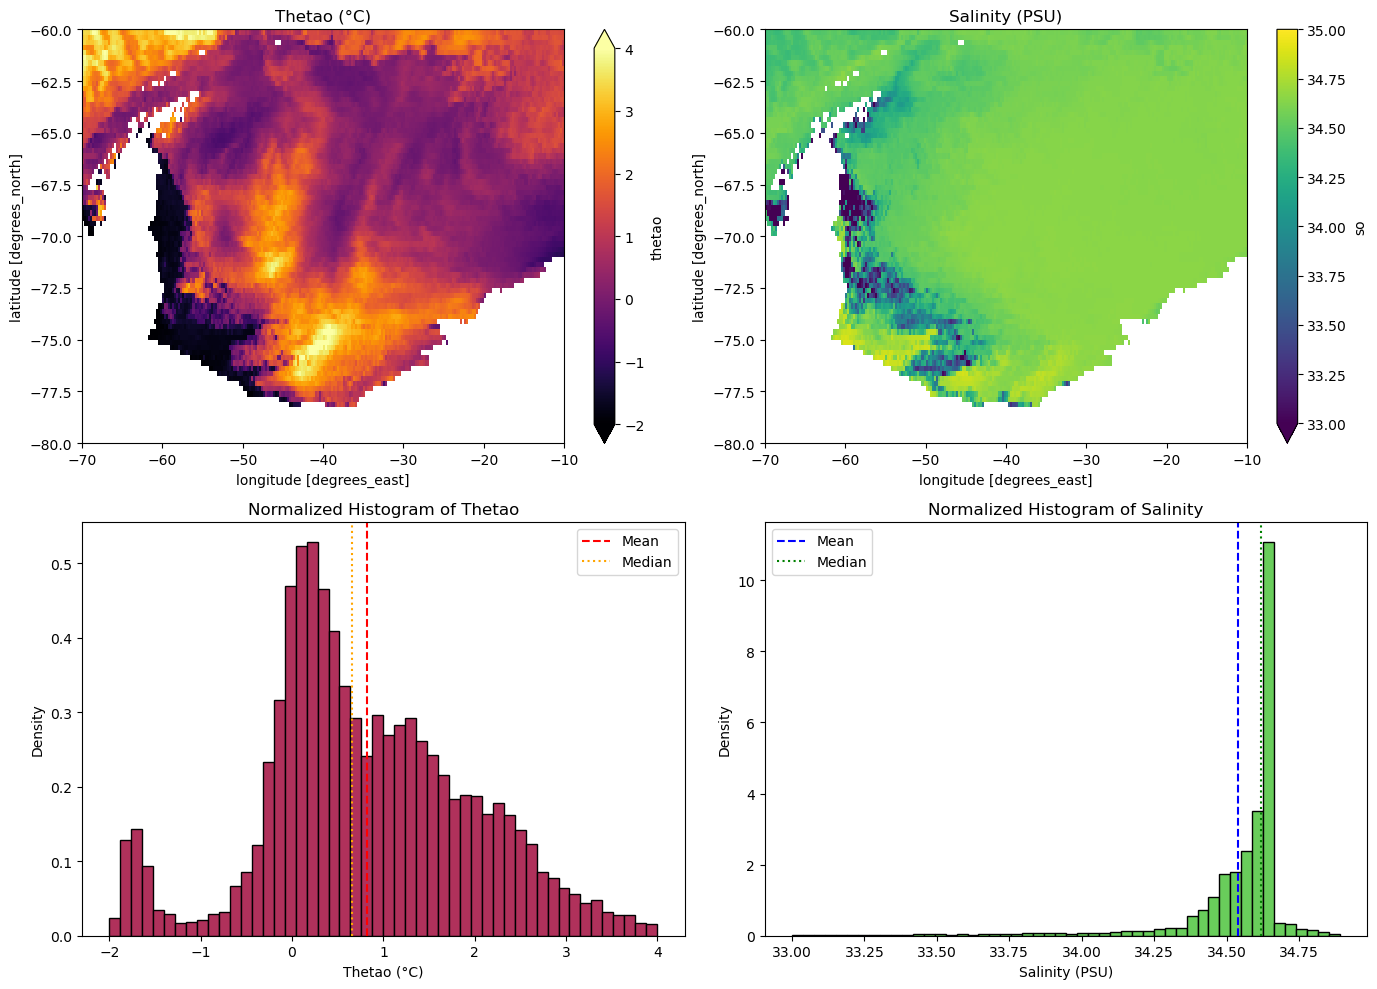

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Extract first time slice
thetao = ds_regridded["thetao"].isel(time_counter=0)
so = ds_regridded["so"].isel(time_counter=0)

# --------------------------
# Map vlims
thetao_vmin, thetao_vmax = -2, 4
so_vmin, so_vmax = 33, 35

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# --------------------------
# Map plots with fixed vmin/vmax
thetao.plot(ax=axes[0,0], cmap="inferno", vmin=thetao_vmin, vmax=thetao_vmax)
axes[0,0].set_title("Thetao (°C)")

so.plot(ax=axes[0,1], cmap="viridis", vmin=so_vmin, vmax=so_vmax)
axes[0,1].set_title("Salinity (PSU)")

# --------------------------
# Flatten arrays and clip to vlims
thetao_vals = thetao.values.ravel()
thetao_vals = thetao_vals[~np.isnan(thetao_vals)]
thetao_vals = thetao_vals[(thetao_vals >= thetao_vmin) & (thetao_vals <= thetao_vmax)]

so_vals = so.values.ravel()
so_vals = so_vals[~np.isnan(so_vals)]
so_vals = so_vals[(so_vals >= so_vmin) & (so_vals <= so_vmax)]

# --------------------------
# Choose mean-color from colormap for histograms
thetao_norm = mcolors.Normalize(vmin=thetao_vmin, vmax=thetao_vmax)
thetao_cmap = cm.inferno
thetao_color = thetao_cmap(thetao_norm(thetao_vals.mean()))

so_norm = mcolors.Normalize(vmin=so_vmin, vmax=so_vmax)
so_cmap = cm.viridis
so_color = so_cmap(so_norm(so_vals.mean()))

# --------------------------
# Thetao histogram
axes[1,0].hist(thetao_vals, bins=50, color=thetao_color, edgecolor="k", density=True)
axes[1,0].axvline(thetao_vals.mean(), color="red", linestyle="--", label="Mean")
axes[1,0].axvline(np.median(thetao_vals), color="orange", linestyle=":", label="Median")
axes[1,0].set_xlabel("Thetao (°C)")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Normalized Histogram of Thetao")
axes[1,0].legend()

# Salinity histogram
axes[1,1].hist(so_vals, bins=50, color=so_color, edgecolor="k", density=True)
axes[1,1].axvline(so_vals.mean(), color="blue", linestyle="--", label="Mean")
axes[1,1].axvline(np.median(so_vals), color="green", linestyle=":", label="Median")
axes[1,1].set_xlabel("Salinity (PSU)")
axes[1,1].set_ylabel("Density")
axes[1,1].set_title("Normalized Histogram of Salinity")
axes[1,1].legend()

plt.tight_layout()
plt.show()

